In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import arviz as az

In [2]:
# Find the repo root by searching upwards for src/hrmodel
here = Path.cwd()
for p in (here, *here.parents):
    if (p / "src" / "hrmodel").exists():
        REPO = p
        break
else:
    raise RuntimeError("Could not find repo root containing src/hrmodel")

# Put src/ on sys.path (front so it wins)
sys.path.insert(0, str(REPO / "src"))

# Import from your package
from hrmodel import (
    load_idata_and_preds,
    get_latest_batter_pitcher_data,
    plot_trace_summary,
    summarize_posterior, 
    sweep_thresholds,
    pick_by_precision_floor,
    posterior_hr_prob,
    plot_hr_prob
)

## TODO:

Find out how to make it so it loads in the most recent folder

In [3]:
path_full = "/Users/samuelgartenstein/Desktop/mlb-hr-predictions_test/artifacts/models/full/2025-09-18_09-14-33/idata.nc"
path_noprev = "/Users/samuelgartenstein/Desktop/mlb-hr-predictions_test/artifacts/models/noprev/2025-09-18_09-14-33/idata.nc"

idata_full,  y_true, p_full   = load_idata_and_preds(path_full)
idata_nprev, _,      p_nprev  = load_idata_and_preds(path_noprev)

In [4]:
# Load the at-bats dataset from Google Drive
at_bats_2025 = pd.read_csv("data/at_bats_2025.csv")

# Assign unique indices
at_bats_2025["batter_idx"] = at_bats_2025["batter_name"].astype("category").cat.codes
at_bats_2025["pitcher_idx"] = at_bats_2025["pitcher_name"].astype("category").cat.codes
at_bats_2025["ballpark_idx"] = at_bats_2025["home_team"].astype("category").cat.codes

hand_num = at_bats_2025["p_throws"].map({"R": 0, "L": 1}).fillna(0).values
at_bats_2025["hand_num"] = hand_num

at_bats_2025.head()

,game_date,pitcher_name,home_team,away_team,inning,inning_topbot,at_bat_number,batter_name,batter_id,pitch_number,...,starting_pitcher,barrel,rolling_batter_barrel_rate,rolling_pitcher_barrel_rate,home_run,prev_game_hr,batter_idx,pitcher_idx,ballpark_idx,hand_num
0,2025-03-18,"Buehler, Walker",NYY,BOS,1,Bot,6,Aaron Judge,592450,4,...,1,0,0.152080,0.000000,0,0,0,130,19,0
1,2025-03-18,"Buehler, Walker",NYY,BOS,4,Bot,25,Aaron Judge,592450,3,...,1,1,0.000000,0.200000,0,0,0,130,19,0
2,2025-03-18,"Buehler, Walker",NYY,BOS,5,Bot,37,Aaron Judge,592450,4,...,1,0,0.500000,0.210526,0,0,0,130,19,0
3,2025-03-19,"Schwellenbach, Spencer",NYY,ATL,1,Bot,6,Aaron Judge,592450,4,...,1,0,0.333333,0.000000,0,0,0,843,19,0
4,2025-03-19,"Schwellenbach, Spencer",NYY,ATL,4,Bot,25,Aaron Judge,592450,3,...,1,0,0.250000,0.000000,0,0,0,843,19,0


## Diagnostics

### Posterior Trace Plots

The figure below shows trace plots and posterior densities for the key model parameters. These plots are useful for assessing MCMC convergence and visualizing the posterior distributions. Stable chains without strong trends or divergences indicate good mixing, while the density plots summarize the estimated parameter values.

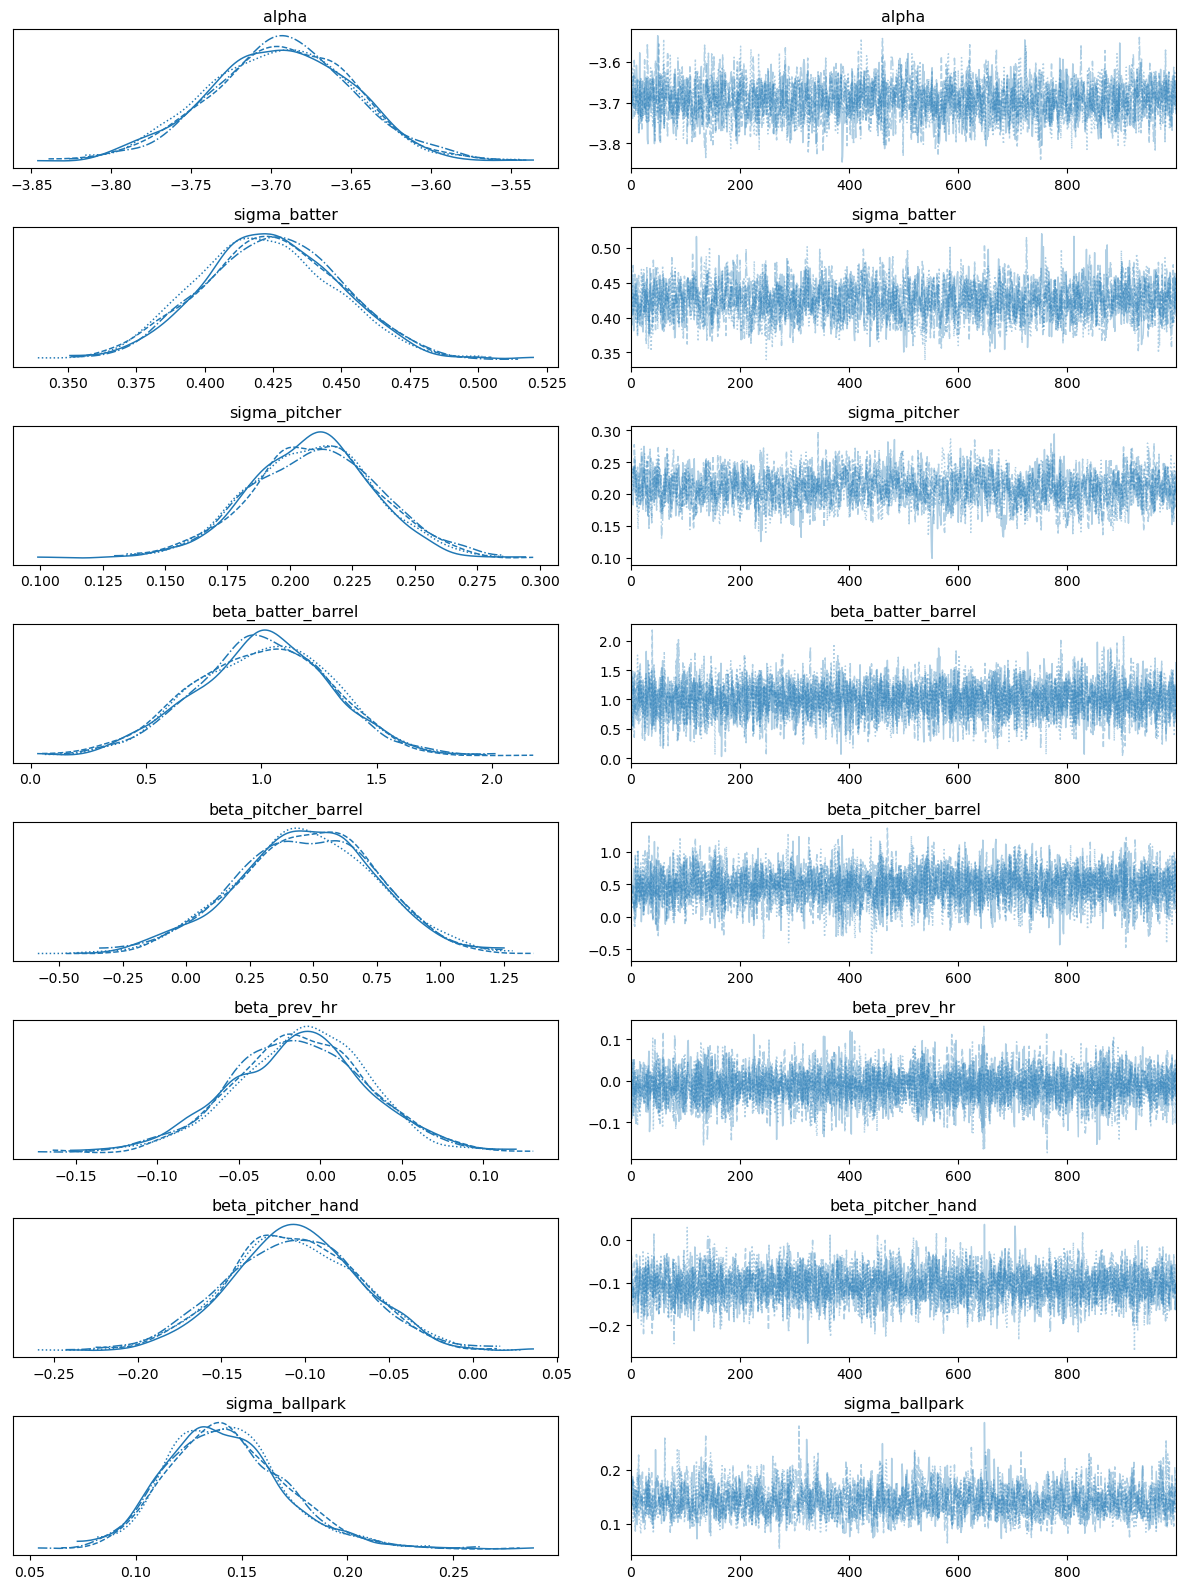

In [5]:
var_names = [
    "alpha",
    "sigma_batter",
    "sigma_pitcher",
    "beta_batter_barrel",
    "beta_pitcher_barrel",
    "beta_prev_hr",
    "beta_pitcher_hand",
    "sigma_ballpark",
]


plot_trace_summary(idata_full, var_names=var_names)

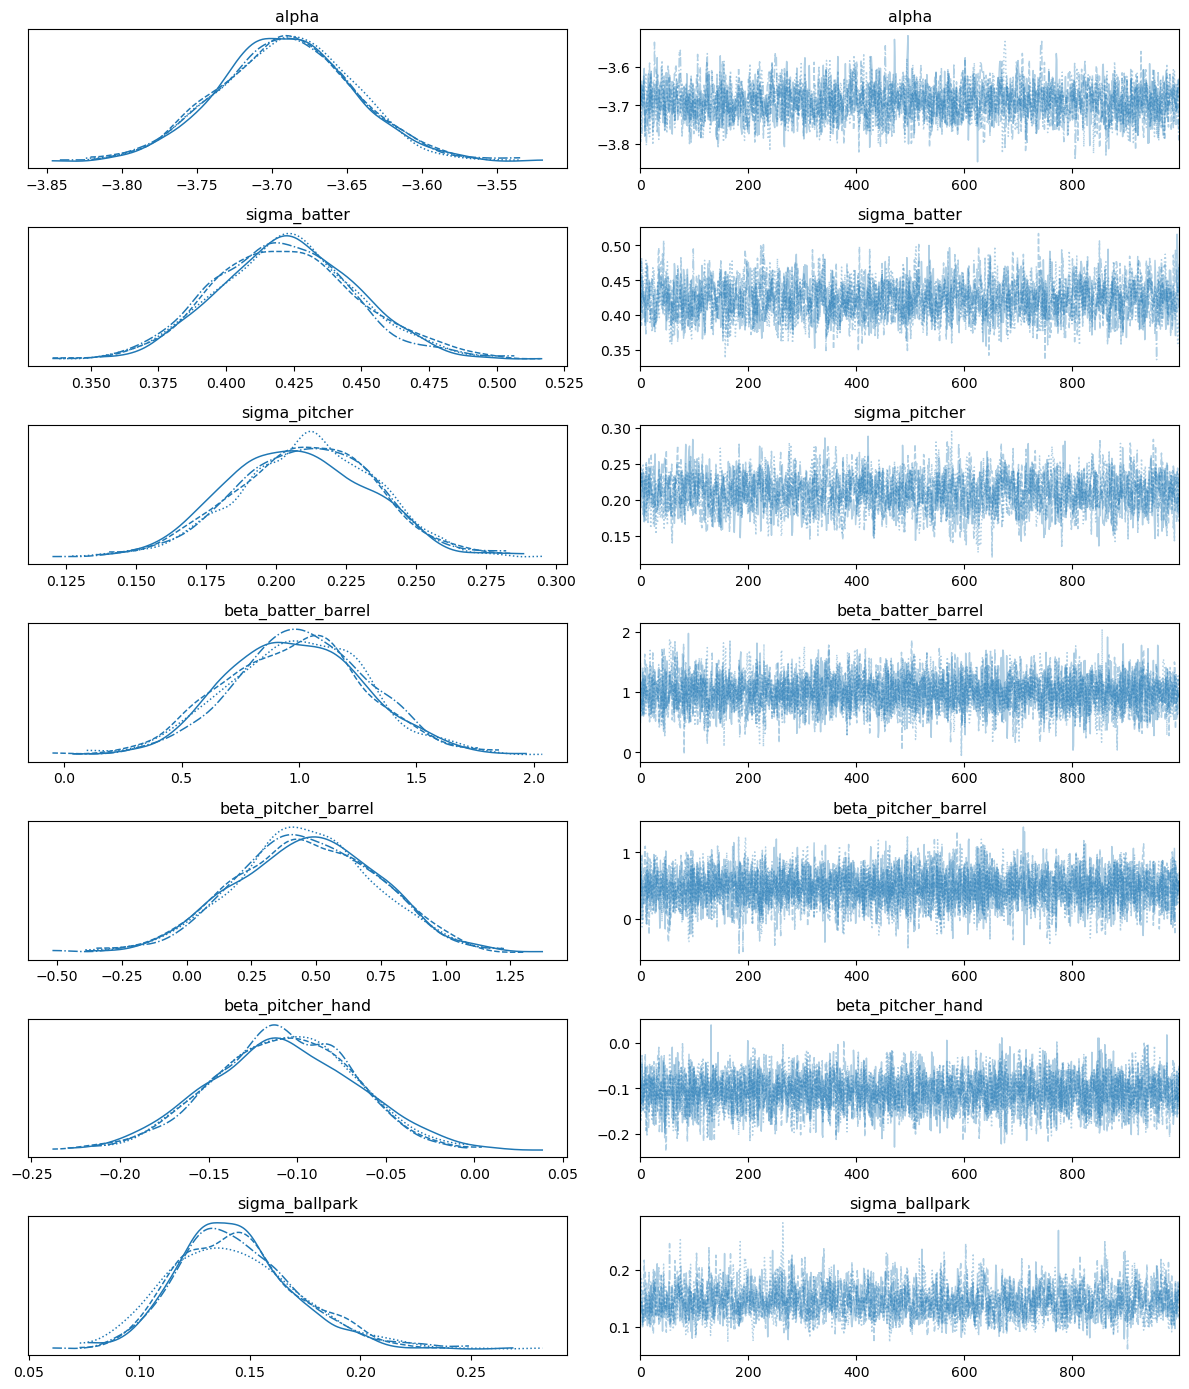

In [6]:
plot_trace_summary(
    idata_nprev,
    var_names=[v for v in var_names if v in idata_nprev.posterior.data_vars]
)

### Posterior Summary

The table below reports posterior means, standard deviations, and 95% credible intervals for the main model coefficients. The 95% credible interval represents the range within which the parameter lies with 95% posterior probability, providing a measure of uncertainty around each effect estimate.

In [7]:
summarize_posterior(idata_full, var_names=var_names)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-3.694,0.045,-3.790,-3.612,0.001,0.001,2100.995,2755.805,1.000
sigma_batter,0.424,0.025,0.374,0.472,0.001,0.000,1537.980,2421.455,1.002
sigma_pitcher,0.209,0.025,0.160,0.260,0.001,0.001,856.948,1650.473,1.004
beta_batter_barrel,1.004,0.299,0.394,1.560,0.004,0.003,4909.260,2823.738,1.001
beta_pitcher_barrel,0.471,0.276,-0.082,0.994,0.004,0.003,3851.393,2541.089,1.000
beta_prev_hr,-0.012,0.042,-0.095,0.069,0.001,0.001,6566.118,2528.723,1.000
beta_pitcher_hand,-0.107,0.039,-0.183,-0.032,0.001,0.000,4230.459,3385.494,1.002
sigma_ballpark,0.143,0.028,0.091,0.199,0.001,0.000,1664.822,2432.383,1.001


### Model: LOO and Posterior Predictive

LOO estimates out-of-sample predictive accuracy by approximating leave-one-out cross-validation from a single posterior fit. In practice, ArviZ’s PSIS-LOO takes the posterior log-likelihood draws for each observation, applies Pareto-smoothed importance sampling to approximate the refit that would occur if that observation were omitted, and aggregates the per-observation contributions into the expected log pointwise predictive density, `elpd_loo` (larger is better). It also reports diagnostics such as Pareto-$k$, which flag influential observations where the approximation is less reliable.

Since the data has over 100,000 observations, using the full PSIS-LOO is memory-intensive because the log-likelihood tensor scales with chains × draws × observations. To keep computation tractable while preserving a faithful comparison, the following was done:

- Retain all chains but thin the MCMC draws by using every 5th draw
- Down-cast log-likelihood to float32, which halves memory usage with negligible impact on model ranking
- Use a minimal object for LOO by providing only the `log_likelihood` to PSIS-LOO, omitting other posterior groups.
-  **Provide and justify relative efficiency:** because the posterior group is absent, pass a scalar $\text{reff}$ so ArviZ can proceed; $\text{reff} = \frac{\text{ESS}}{N}$ summarizes how many independent draws the sample effectively contains after autocorrelation. Setting $\text{reff} = 1.0$ assumes near-independent draws and chiefly affects uncertainty (standard errors) and diagnostics rather than the ELPD point estimates.


In [8]:
ll_n = idata_nprev.log_likelihood["y_obs"].sel(chain=[0,1,2,3], draw=slice(None, None, 5)).astype("float32")
ll_f = idata_full.log_likelihood["y_obs"].sel(chain=[0,1,2,3], draw=slice(None, None, 5)).astype("float32")

loo_n = az.loo(az.from_dict(log_likelihood={"y_obs": ll_n}), pointwise=True, reff=1.0)
loo_f = az.loo(az.from_dict(log_likelihood={"y_obs": ll_f}), pointwise=True, reff=1.0)

In [9]:
# now compare works
comp = az.compare({"noprev": loo_n, "full": loo_f}, ic="loo")
comp


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
noprev,0,-24079.868962,467.629220,0.000000,0.980791,247.738496,0.000000,False,log
full,1,-24080.529835,466.761629,0.660872,0.019209,247.657799,1.171363,False,log


## Accuracy Metrics

To evaluate the classifier, focus on precision, recall, and the resulting alert volume at a chosen probability threshold $t$. Precision and recall are defined as

$$
\text{Precision}=\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}},\qquad
\text{Recall}=\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}\,,
$$
where:
- **TP** = true positives (home runs correctly classified as home runs)  
- **FP** = false positives (non–home runs incorrectly classified as home runs)  
- **FN** = false negatives (home runs incorrectly classified as non–home runs)

Each plate appearance has a predicted home-run probability $p_i$. An at-bat is classified as a home run when $p_i \ge t$, where $t$ is the decision threshold.

**Alerts.** At threshold $t$, alerts are the number of plate appearances flagged positive:

$$
\text{Alerts}=\sum_{i=1}^{N}\mathbf{1}[\,p_i \ge t\,] \;=\; \mathrm{TP}+\mathrm{FP}.
$$

- $\mathbf{1}[\cdot]$ = indicator (1 if the condition is true, 0 otherwise)

Alerts depend only on the predictions and the chosen threshold $t$. The split into $\mathrm{TP}$ and $\mathrm{FP}$ requires ground-truth labels.

*Because home runs are rare, thresholds below $0.5$ are often used to balance precision, recall, and alert volume.*


Below, we will evaluate the metrics at various threshold and minimum precision levels, using the following steps:

1. **Build a threshold grid.**  
   Create a sequence of candidate probability cutoffs $t \in [0.03, 0.08]$ in increments of $0.001$. For each $t$, predictions are $\mathbf{1}[p_i \ge t]$.

2. **Sweep performance across thresholds.**  
   For every $t$ in the grid, compute the **precision**, **recall**, and **alerts** as defined above and collect counts **TP**, **FP**, **FN**.

3. **Specify candidate precision floors.**  
   Choose target precision levels between $0.070$ and $0.090$ in increments of $0.005$ that encode a minimum acceptable alert quality.

4. **Select an operating point per floor.**  
   For each floor $f$, pick the threshold $t^*$ that meets/exceeds the floor,
   $
   \text{Precision} \ge f,
   $
   and among feasible thresholds **maximizes recall**, using a tie-break rule if needed.


The resulting DataFrame summarizes, for each precision floor, the chosen $t^*$ and the corresponding precision, recall, alerts, TP, FP, FN, and a flag `met_floor` indicating whether the floor was actually satisfied.


**Sources**

https://www.nb-data.com/p/understanding-f-beta-for-model-evaluation

https://medium.com/@piyushkashyap045/understanding-precision-recall-and-f1-score-metrics-ea219b908093

In [11]:
# 1) Sweep thresholds once
ths   = np.linspace(0.03, 0.08, 51)
sweep = sweep_thresholds(y_true, {"noprev": p_nprev}, ths)

# 2) Try a few candidate precision floors and see recall/alerts
floors = np.linspace(0.07, 0.09, 9)
choices = [pick_by_precision_floor(sweep, floor=f).assign(floor=f) for f in floors]
choices = pd.concat(choices)
choices

,threshold,precision,recall,alerts,tp,fp,fn,floor,met_floor
model,,,,,,,,,
noprev,0.049,0.071132,0.199891,15422,1097,14325,4391,0.0700,True
noprev,0.050,0.073319,0.187318,14021,1028,12993,4460,0.0725,True
noprev,0.052,0.076963,0.163630,11668,898,10770,4590,0.0750,True
noprev,0.054,0.078623,0.139395,9730,765,8965,4723,0.0775,True
noprev,0.057,0.082053,0.110969,7422,609,6813,4879,0.0800,True
noprev,0.059,0.084145,0.096028,6263,527,5736,4961,0.0825,True
noprev,0.060,0.086565,0.091108,5776,500,5276,4988,0.0850,True
noprev,0.061,0.087966,0.085641,5343,470,4873,5018,0.0875,True
noprev,0.064,0.091259,0.069060,4153,379,3774,5109,0.0900,True


## Prediction

With the model trained, we can predict the home-run probability for a matchup. First, we pull each player’s most recent row and compute 40-game rolling barrel rates using only data up to game t. Then we feed those features—along with other covariates and the indices for the random and fixed effects—into the posterior to obtain the home-run probability.

In [12]:
# Most recent ABs for Trent Grisham AND Aaron Judge
batter_df, _ = get_latest_batter_pitcher_data(
    at_bats_2025,
    batters=["Trent Grisham", "Aaron Judge"]
)

# Just get Cabrera, Edward's most recent pitching appearance
_, pitcher_df = get_latest_batter_pitcher_data(at_bats_2025, pitchers="Povich, Cade")

display(batter_df)

display(pitcher_df)

,game_date,home_team,away_team,batter_name,batter_id,rolling_batter_barrel_rate,batter_idx
0,2025-09-17,MIN,NYY,Trent Grisham,663757,0.100,653
1,2025-09-17,MIN,NYY,Aaron Judge,592450,0.175,0


,game_date,home_team,away_team,pitcher_name,rolling_pitcher_barrel_rate,pitcher_idx,hand_num
0,2025-09-11,BAL,PIT,"Povich, Cade",0.05,742,1


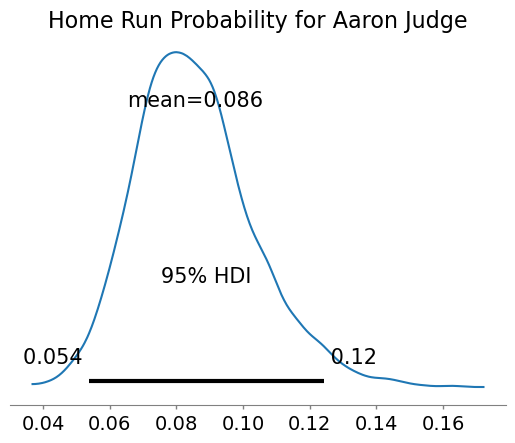

Aaron Judge vs Povich, Cade (park 3): 0.0856 (95% HDI 0.0538–0.1242)


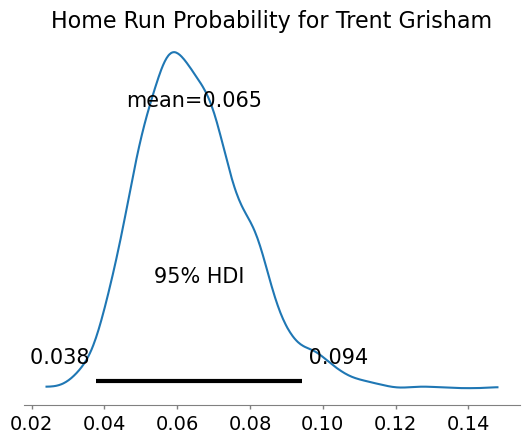

Trent Grisham vs Povich, Cade (park 3): 0.0645 (95% HDI 0.0377–0.0944)


In [13]:
# List the matchups you want to plot: (batter_name, pitcher_name, ballpark_idx, prev_hr_flag)
matchups = [
    ("Aaron Judge",   "Povich, Cade", 3, 0),
    ("Trent Grisham", "Povich, Cade", 3, 0),
]

for batter, pitcher, park, prev_flag in matchups:
    mean_p, lo, hi = plot_hr_prob(
        idata_nprev,
        batter_df=batter_df, pitcher_df=pitcher_df,
        batter_name=batter,
        pitcher_name=pitcher,
        ballpark_idx=park,
        prev_hr_flag=prev_flag,
        plot=True,   # this triggers the plot
    )
    print(f"{batter} vs {pitcher} (park {park}): {mean_p:.4f} (95% HDI {lo:.4f}–{hi:.4f})")